In [1]:
from dotenv import load_dotenv
import os

In [2]:
load_dotenv()
data_path = os.getenv("DATA_PATH")

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [4]:
df = pd.read_csv(data_path)

In [5]:
df.replace("?", np.nan, inplace=True)

In [8]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,NaN,77053,HS-grad,9,Widowed,NaN,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,NaN,186061,Some-college,10,Widowed,NaN,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [ ]:

print("Dataset Shape:", df.shape) # rows & cols
print("Dataset Dimension:", df.ndim)  # dimension
df.info()
df.describe()

Dataset Shape: (32561, 15)
Dataset Dimension: 2
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       30725 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      30718 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  31978 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [7]:
print( df.isnull().sum())

age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64


In [9]:
for col in ["workclass","occupation","native.country"] :
    df[col].fillna(df[col].mode()[0],inplace=True)

print("\nMissing values after handling:\n")
print(df[['workclass', 'occupation', 'native.country']].isnull().sum())


Missing values after handling:

workclass         0
occupation        0
native.country    0
dtype: int64


In [11]:
# Check duplicate rows
print("Number of duplicate rows:", df.duplicated().sum())
df.drop_duplicates(inplace=True)

print("Shape after removing duplicates:", df.shape)


Number of duplicate rows: 24
Shape after removing duplicates: (32537, 15)


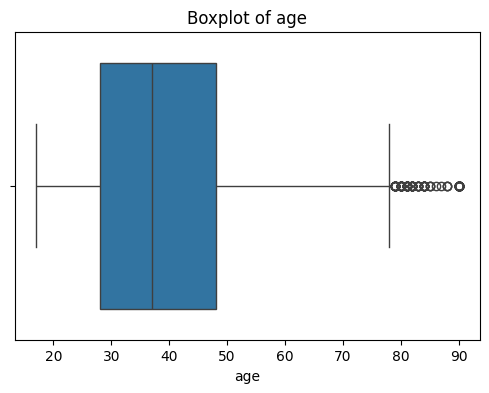

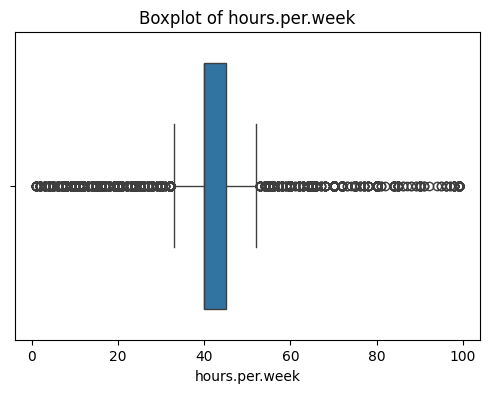

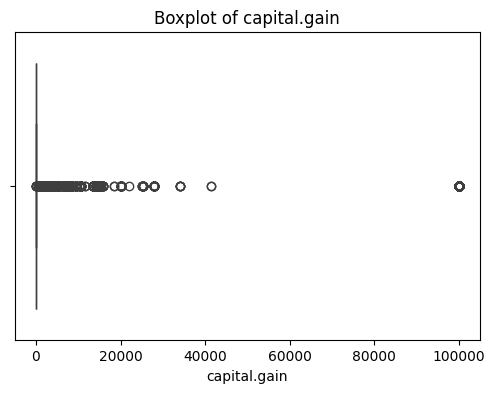

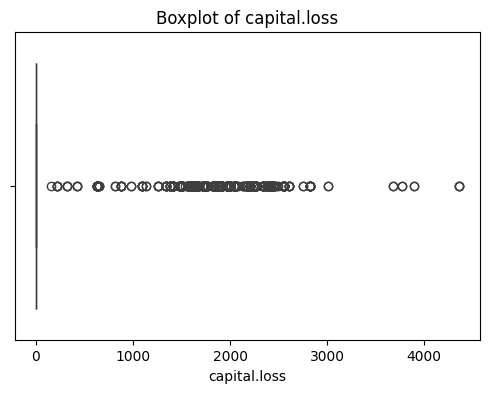

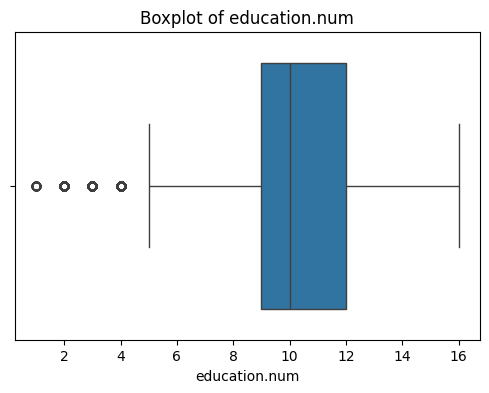

In [12]:
numerical_cols = ['age', 'hours.per.week', 'capital.gain', 
                  'capital.loss', 'education.num']

for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()


In [13]:
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

print("Shape after IQR outlier removal:", df.shape)


Shape after IQR outlier removal: (19606, 15)


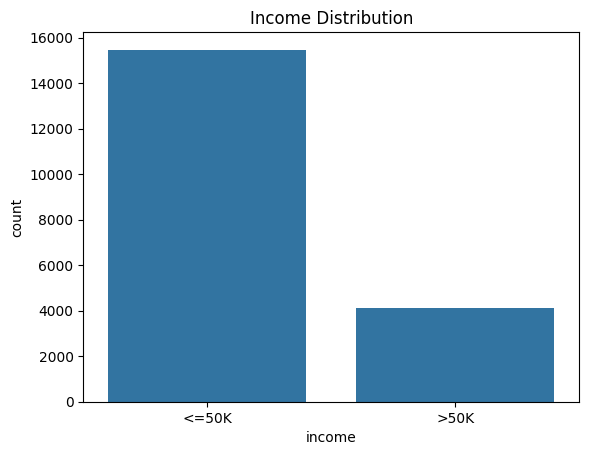

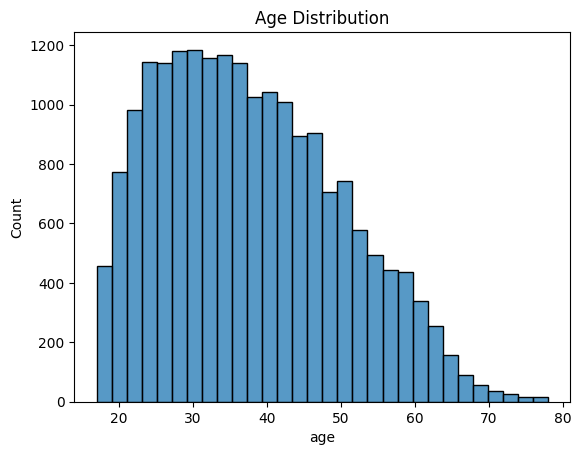

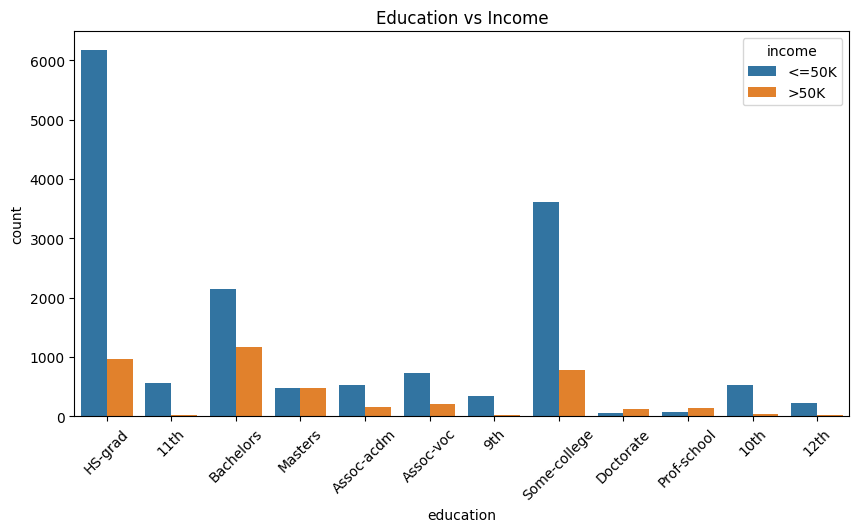

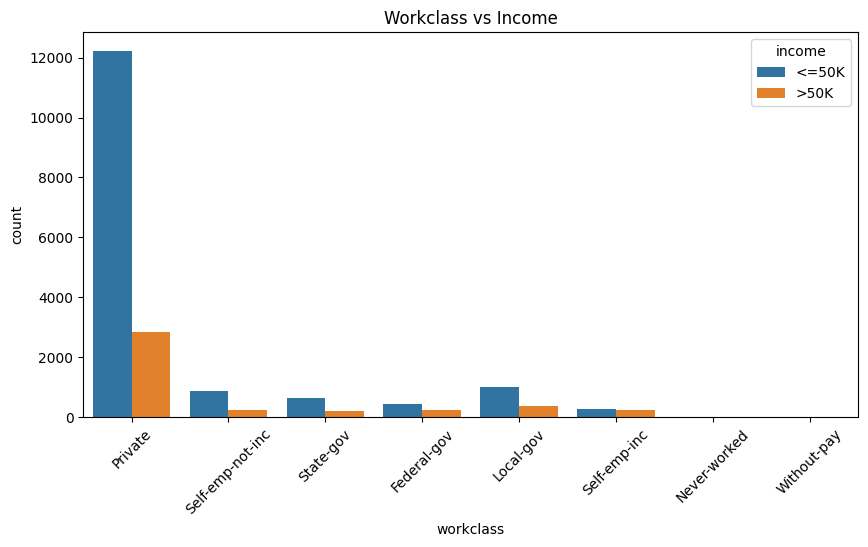

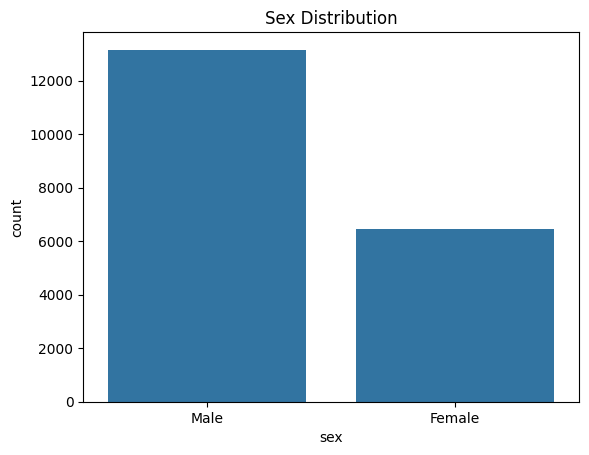

In [18]:
plt.figure()
sns.countplot(data=df,x="income")
plt.title("Income Distribution")
plt.show()

plt.figure()
sns.histplot(data=df["age"],bins=30)
plt.title("Age Distribution")
plt.show()

plt.figure(figsize=(10,5))
sns.countplot(x='education', hue='income', data=df)
plt.xticks(rotation=45)
plt.title("Education vs Income")
plt.show()

plt.figure(figsize=(10,5))
sns.countplot(x='workclass', hue='income', data=df)
plt.xticks(rotation=45)
plt.title("Workclass vs Income")
plt.show()

plt.figure()
sns.countplot(data=df,x="sex")
plt.title("Sex Distribution")
plt.show()



In [19]:
df_encoded = df.copy()

# Encode all categorical columns
for col in df_encoded.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    

In [20]:
X = df_encoded.drop("income", axis=1)
y = df_encoded["income"]

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)


In [23]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:\n", y_train.value_counts())
print("\nAfter SMOTE:\n", y_train_smote.value_counts())



Before SMOTE:
 income
0    12375
1     3309
Name: count, dtype: int64

After SMOTE:
 income
0    12375
1    12375
Name: count, dtype: int64


In [25]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(y_pred)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

[0 0 0 ... 0 0 0]
Accuracy: 0.818969913309536

Confusion Matrix:
 [[2950  145]
 [ 565  262]]

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.95      0.89      3095
           1       0.64      0.32      0.42       827

    accuracy                           0.82      3922
   macro avg       0.74      0.63      0.66      3922
weighted avg       0.80      0.82      0.79      3922



In [26]:
model = DecisionTreeClassifier(
    criterion="entropy", 
    max_depth=10,             
    min_samples_split=10,
    min_samples_leaf=5,
    max_features="sqrt",
    random_state=42)
model.fit(X_train, y_train)


y_pred = model.predict(X_test)



print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8268740438551759

Confusion Matrix:
 [[2937  158]
 [ 521  306]]

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.95      0.90      3095
           1       0.66      0.37      0.47       827

    accuracy                           0.83      3922
   macro avg       0.75      0.66      0.69      3922
weighted avg       0.81      0.83      0.81      3922



In [27]:
rf_model = RandomForestClassifier(
    n_estimators=200,          # number of trees
    criterion="gini",
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    bootstrap=True,
    random_state=42,
    n_jobs=-1                  # use all CPU cores
)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("\n===== Random Forest Results =====")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, rf_pred))
print("\nClassification Report:\n", classification_report(y_test, rf_pred))


===== Random Forest Results =====
Accuracy: 0.8470168281489037

Confusion Matrix:
 [[2931  164]
 [ 436  391]]

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.95      0.91      3095
           1       0.70      0.47      0.57       827

    accuracy                           0.85      3922
   macro avg       0.79      0.71      0.74      3922
weighted avg       0.84      0.85      0.84      3922

